In [ ]:
# import all packages used in this file
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
import re
import nltk
from nltk.corpus import stopwords
import torch
from transformers import BertTokenizer, BertForSequenceClassification
from torch.nn.functional import softmax
# evaluation metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.stats import pearsonr
from sklearn.metrics import r2_score

#import tensorflow as tf
#from sklearn.metrics import accuracy_score, confusion_matrix
#import seaborn as sns
#from sklearn.model_selection import train_test_split
#from tensorflow.keras.models import Sequential
#from tensorflow.keras.layers import LSTM, Dense, Dropout

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import adfuller

In [ ]:
# load data
drive.mount('/content/drive')
raw_data = pd.read_pickle("/content/drive/My Drive/levis_reviews.pkl")
# convert json format reviews into separate columns
df_expanded = raw_data.explode('Reviews')
df_expanded = df_expanded.reset_index(drop=True)
reviews_normalized = pd.json_normalize(df_expanded['Reviews'])
df_final = pd.concat([df_expanded.drop(columns=['Reviews']), reviews_normalized], axis=1)
# combine review title and comment
df_final['comment'] = df_final['Review Title'] + '\n' + df_final['comment']
df_final = df_final.drop(columns=['Review Title'])
df_final = df_final.dropna(subset=['Rating'])
df_final['Rating'] = df_final['Rating'].astype(int)
df_shuffled = df_final.sample(frac=1).reset_index(drop=True)
product_name = df_shuffled['Product Name'].iloc[0]
data = df_shuffled.head(1000)  # [df_shuffled['Product Name'] == product_name]
print(data.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
                   Product Name  Product Type  \
0     511™ Slim Fit Men's Jeans  High Stretch   
1  550™ Relaxed Fit Men's Jeans    No Stretch   
2  550™ Relaxed Fit Men's Jeans    No Stretch   
3     511™ Slim Fit Men's Jeans  High Stretch   
4  550™ Relaxed Fit Men's Jeans    No Stretch   

                                             Ratings Number of Reviews  \
0  {'5': 2254, '4': 329, '3': 185, '2': 140, '1':...              3180   
1  {'5': 2597, '4': 448, '3': 258, '2': 201, '1':...              3933   
2  {'5': 2597, '4': 448, '3': 258, '2': 201, '1':...              3933   
3  {'5': 2254, '4': 329, '3': 185, '2': 140, '1':...              3180   
4  {'5': 2597, '4': 448, '3': 258, '2': 201, '1':...              3933   

   Average Rate  Price_cleaned  Reviewer Name  Verified  Sweepstakes Entry  \
0          4.31          45.98  childofgodMom      Tr

In [ ]:
# load BERT model and Tokenizer
model_name = 'nlptown/bert-base-multilingual-uncased-sentiment'
tokenizer = BertTokenizer.from_pretrained(model_name)
model = BertForSequenceClassification.from_pretrained(model_name)
# ensure that the model runs on GPU, if applicable
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(105879, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1

In [ ]:
# define a function to compute text sentiment score
def get_sentiment_score(text):
    # encode text to BERT input format
    inputs = tokenizer(text, return_tensors='pt', truncation=True, padding=True, max_length=512)
    inputs = {key: value.to(device) for key, value in inputs.items()}
    # use BERT
    with torch.no_grad():
        outputs = model(**inputs)
    # get the output and compute softmax probabilities
    probs = softmax(outputs.logits, dim=-1)
    # convert the probabilities to [-1,1] sentiment scores
    sentiment_score = (probs[0][4].item() - probs[0][0].item())
    return sentiment_score

In [ ]:
# apply the function and store results in a new column
data['Sentiment Score'] = data['comment'].apply(get_sentiment_score)
print(data.head())

                                 Product Name    Product Type  \
0  721 High Rise Skinny Utility Women's Jeans  Medium Stretch   
1              312 Shaping Slim Women's Jeans  Medium Stretch   
2                   511™ Slim Fit Men's Jeans    High Stretch   
3              312 Shaping Slim Women's Jeans  Medium Stretch   
4                550™ Relaxed Fit Men's Jeans      No Stretch   

                                             Ratings Number of Reviews  \
0     {'5': 346, '4': 70, '3': 30, '2': 34, '1': 32}               512   
1    {'5': 875, '4': 183, '3': 92, '2': 53, '1': 87}              1290   
2  {'5': 2254, '4': 329, '3': 185, '2': 140, '1':...              3180   
3    {'5': 875, '4': 183, '3': 92, '2': 53, '1': 87}              1290   
4  {'5': 2597, '4': 448, '3': 258, '2': 201, '1':...              3933   

   Average Rate  Price_cleaned Reviewer Name  Verified  Sweepstakes Entry  \
0          4.30          69.50       Barbara      True              False   
1         

<ipython-input-22-b0f428cc2d1c>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Sentiment Score'] = data['comment'].apply(get_sentiment_score)


Now apply some evaluation metrics to check if the predicted sentiment scores align with the pattern of ratings in the original dataset.

In [ ]:
# create a new column mapping [1,5] onto [-1,1]
data['Scaled Rating'] = 0.5*(data['Rating']-1)-1
# compute RMSE
rmse = np.sqrt(mean_squared_error(data['Scaled Rating'], data['Sentiment Score']))
# compute MAE
mae = mean_absolute_error(data['Scaled Rating'], data['Sentiment Score'])
print(f"RMSE between Scaled Rating and Sentiment Score: {rmse:.4f}")
print(f"MAE between Scaled Rating and Sentiment Score: {mae:.4f}")

RMSE between Scaled Rating and Sentiment Score: 0.4210
MAE between Scaled Rating and Sentiment Score: 0.3246


<ipython-input-23-3b6ff806a701>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Scaled Rating'] = 0.5*(data['Rating']-1)-1


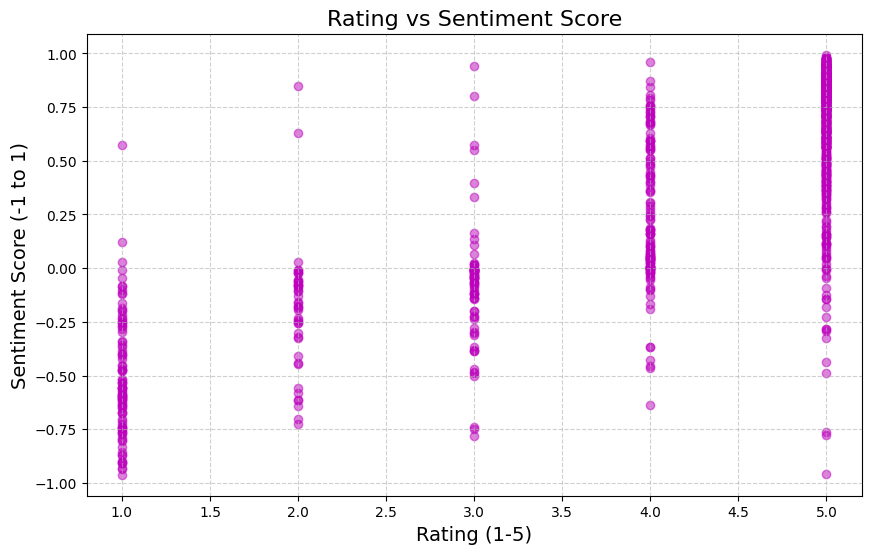

In [ ]:
# scatterplot of original ratings v.s. predicted sentiment scores
plt.figure(figsize=(10, 6))
plt.scatter(data['Rating'], data['Sentiment Score'], alpha=0.5, color='m')
plt.title('Rating vs Sentiment Score', fontsize=16)
plt.xlabel('Rating (1-5)', fontsize=14)
plt.ylabel('Sentiment Score (-1 to 1)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
# compute Pearson correlation
pearson_corr, _ = pearsonr(data['Scaled Rating'], data['Sentiment Score'])
# compute R-squared
r2 = r2_score(data['Scaled Rating'], data['Sentiment Score'])
print(f"Pearson Correlation between Scaled Rating and Sentiment Score: {pearson_corr:.4f}")
print(f"R² between Scaled Rating and Sentiment Score: {r2:.4f}")

Pearson Correlation between Scaled Rating and Sentiment Score: 0.8148
R² between Scaled Rating and Sentiment Score: 0.5820


In [ ]:
data['Review Date(months ago)'] = data['Review Date(months ago)'].astype(float)
data = data.sort_values(by='Review Date(months ago)', ascending=False)
data['Price_cleaned'] = data['Price_cleaned'].astype(float)
data['Number of Reviews'] = data['Number of Reviews'].astype(int)
data['Average Rate'] = data['Average Rate'].astype(float)

<ipython-input-3-d09ae9b59f4c>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Review Date(months ago)'] = data['Review Date(months ago)'].astype(float)


In [ ]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 21.2 MB/s eta 0:00:00


In [ ]:
!pip install -q condacolab
import condacolab
condacolab.install()

⏬ Downloading https://github.com/jaimergp/miniforge/releases/download/24.11.2-1_colab/Miniforge3-colab-24.11.2-1_colab-Linux-x86_64.sh...
📦 Installing...
📌 Adjusting configuration...
🩹 Patching environment...
⏲ Done in 0:00:12
🔁 Restarting kernel...


In [ ]:
!conda install -c saravji pmdarima

Channels:
 - saravji
 - conda-forge
Platform: linux-64
Solving environment: | / - \ done

## Package Plan ##

  environment location: /usr/local

  added / updated specs:
    - pmdarima


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    ca-certificates-2025.1.31  |       hbcca054_0         154 KB  conda-forge
    certifi-2025.1.31          |     pyhd8ed1ab_0         159 KB  conda-forge
    conda-24.11.3              |  py311h38be061_0         1.1 MB  conda-forge
    cython-3.0.12              |  py311ha3e34f5_0         3.6 MB  conda-forge
    joblib-1.4.2               |     pyhd8ed1ab_1         215 KB  conda-forge
    libblas-3.9.0              |31_h59b9bed_openblas          16 KB  conda-forge
    libcblas-3.9.0             |31_he106b2a_openblas          16 KB  conda-forge
    libgfortran-14.2.0         |       h69a702a_2          52 KB  conda-forge
    libgfortran5-14.2.0       

In [ ]:
# import all packages used in this file
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
import re
# evaluation metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.stats import pearsonr
from sklearn.metrics import r2_score

#import tensorflow as tf
#from sklearn.metrics import accuracy_score, confusion_matrix
#import seaborn as sns
#from sklearn.model_selection import train_test_split
#from tensorflow.keras.models import Sequential
#from tensorflow.keras.layers import LSTM, Dense, Dropout

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima

In [ ]:
drive.mount('/content/drive')
data = pd.read_pickle("/content/drive/My Drive/df_test_results.pkl")

Mounted at /content/drive


In [ ]:
print(data.head())

   unique_id         user  rating  review date(months ago)             title  \
0         59    Anonymous       1                     24.0        Weak Jeans   
1        268  Zeltnerpack       5                     48.0     Favorite jean   
2         48           CD       5                     24.0           Awesome   
3         32  Luster_omar       5                     12.0  Look n feel nice   
4         14  sandra17487       4                    144.0          Adequate   

                                             comment recommend website  \
0  I recently began replacing my jeans. I purchas...        No   levis   
1  Love the classic straight fit on a shorter, he...       Yes   levis   
2  Love the color. Fit is spot on. Doesn’t get mu...       Yes   levis   
3  Decided to try these because I normally wear s...       Yes   levis   
4  Great style and fit but the weight of the deni...       Yes   levis   

   scaled_recommend  scaled_rating  true_label  predicted_label  \
0      

In [ ]:
data = data.sort_values(by='review date(months ago)', ascending=False)

In [ ]:
data.rename(columns={'predicted_label': 'Sentiment Score'}, inplace=True)

In [ ]:
print(data['unique_id'].unique())

[ 59  63  12  72  37  27  41  61   1  14 105 102  16  25  47  46  67  79
  64  40   5 101  53 147  55  78   6 165 150 151 337 245 237 243  17  39
  96 156  68 378  11 195 397 171 193 315  83 268 183 173  43 175 155  89
   0 168 380  38 241  60  51  70 149 100 157  24   2 167  32  76 239 125
 260  71 362 345  23 184  48  75  58 154 333 191  84  29  85 393 356  88
 201  56 200 178 126  57 103 194  81 299  86  73 310   3]


In [ ]:
#df = data[data['unique_id']==14]
df = data[data['unique_id']==14]
print(df)

       unique_id             user  rating  review date(months ago)  \
1035          14        Bulldog55       5                    180.0   
12516         14        Anonymous       2                    180.0   
7354          14      redonetango       5                    180.0   
11217         14  shuthefrontdoor       5                    168.0   
11904         14           Jane69       5                    168.0   
...          ...              ...     ...                      ...   
12951         14         D. Frtwl       5                     12.0   
46            14            Alice       4                     12.0   
96            14        Anonymous       4                     12.0   
10694         14        MarshallF       3                     12.0   
10716         14               JC       2                     12.0   

                            title  \
1035           Lovin my new 505's   
12516     38 % decrease in weight   
7354            Hard to find size   
11217      

In [ ]:
# split training and test datasets
train_size = int(len(df) * 0.8)
train, test = df.iloc[:train_size], df.iloc[train_size:]

In [ ]:
def check_stationarity(series):
    result = adfuller(series)
    print('ADF Statistic:', result[0])
    print('p-value:', result[1])
    if result[1] <= 0.05:
        print("The time series is stationary.")
    else:
        print("The time series is not stationary.")
    plot_acf(series.dropna(), lags=20)
    plt.show()
    plot_pacf(series.dropna(), lags=20)
    plt.show()

ADF Statistic: -7.137103606845243
p-value: 3.3986006966095615e-10
The time series is stationary.


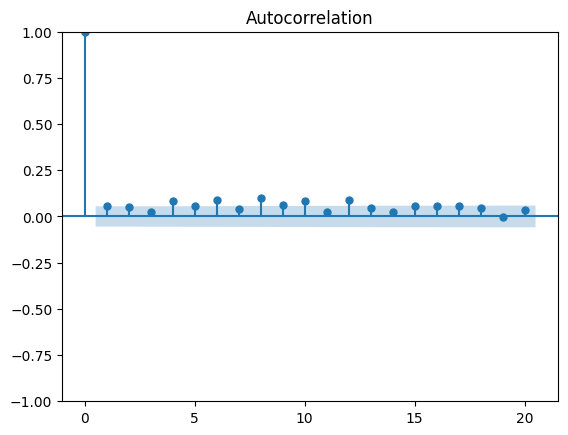

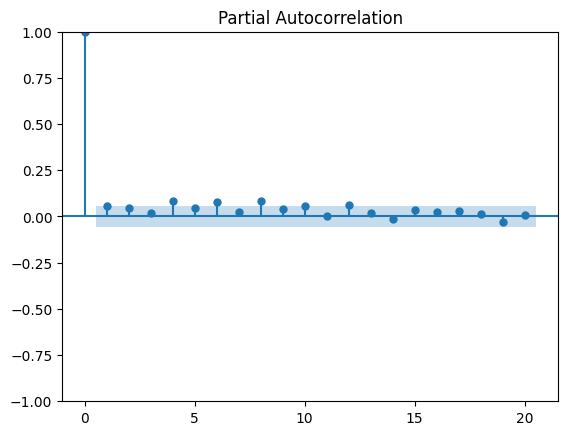

In [ ]:
check_stationarity(train['Sentiment Score'])

In [ ]:
# use auto_arima to deterimine optimal parameters
model = auto_arima(train['Sentiment Score'], seasonal=True, m=12,
                   supress_warnings = True, stepwise = True, trace=True)
print(model.summary())

/usr/local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=2737.802, Time=11.69 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=3576.348, Time=0.15 sec


/usr/local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=3220.494, Time=0.47 sec


/usr/local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


...

 ARIMA(0,1,2)(0,0,2)[12]             : AIC=2733.849, Time=2.34 sec


/usr/local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(1,1,0)(0,0,2)[12]             : AIC=3216.798, Time=2.30 sec


/usr/local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(1,1,2)(0,0,2)[12]             : AIC=2732.701, Time=5.08 sec

Best model:  ARIMA(0,1,1)(0,0,2)[12]          
Total fit time: 89.528 seconds
                                        SARIMAX Results                                        
Dep. Variable:                                       y   No. Observations:                 1269
Model:             SARIMAX(0, 1, 1)x(0, 0, [1, 2], 12)   Log Likelihood               -1361.938
Date:                                 Sat, 22 Mar 2025   AIC                           2731.876
Time:                                         19:48:54   BIC                           2752.457
Sample:                                              0   HQIC                          2739.608
                                                - 1269                                         
Covariance Type:                                   opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-------

In [ ]:
# fit SARIMA model by inputing optimal parameters
model = SARIMAX(train['Sentiment Score'], order=(0, 1, 1), seasonal_order=(0, 0, 2, 12)) # exog=train[['Promotion', 'Competitor_Activity']]
model_fit = model.fit(disp=False)
print(model_fit.summary())

/usr/local/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


                                        SARIMAX Results                                        
Dep. Variable:                         Sentiment Score   No. Observations:                 1269
Model:             SARIMAX(0, 1, 1)x(0, 0, [1, 2], 12)   Log Likelihood               -1361.938
Date:                                 Sat, 22 Mar 2025   AIC                           2731.876
Time:                                         19:49:39   BIC                           2752.457
Sample:                                              0   HQIC                          2739.608
                                                - 1269                                         
Covariance Type:                                   opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.9785      0.007   -149.436      0.000      -0.991      -0

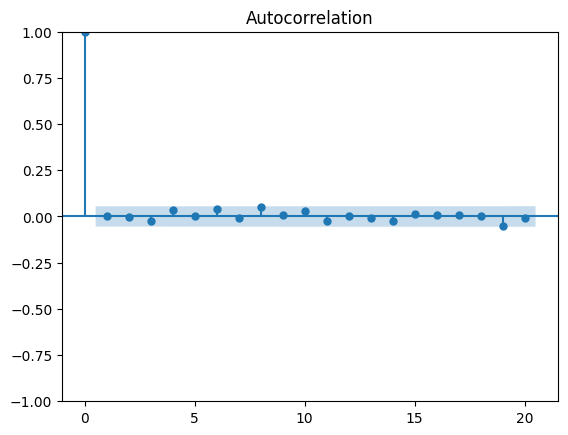

In [ ]:
# residual analysis
residuals = model_fit.resid
plot_acf(residuals, lags=20)
plt.show()

In [ ]:
def ljung_box_test(residuals, lags=20):
    lb_test = acorr_ljungbox(residuals, lags=lags)
    print("Ljung-Box Test Results:")
    print(lb_test)
    # check p-values and print results
    if all(lb_test['lb_pvalue'] > 0.05):
        print("Residual ~ WN. The model fits well.")
    else:
        print("The residuals are autocorrelated. Parameter to be determined...")

In [ ]:
ljung_box_test(residuals)

Ljung-Box Test Results:
      lb_stat  lb_pvalue
1    0.003669   0.951698
2    0.017576   0.991251
3    0.929310   0.818350
4    2.627648   0.621933
5    2.639559   0.755346
6    4.489686   0.610716
7    4.620302   0.706187
8    8.066214   0.427029
9    8.182896   0.515825
10   9.478412   0.487380
11  10.209379   0.511658
12  10.209380   0.597598
13  10.275008   0.671306
14  11.112485   0.677178
15  11.320389   0.729570
16  11.373388   0.785873
17  11.444085   0.832570
18  11.449090   0.874337
19  14.820934   0.733908
20  14.899425   0.782133
Residual ~ WN. The model fits well.


In [ ]:
# forecast future sentiment scores in limited number of steps
forecast = model_fit.forecast(steps=len(test))
print(forecast)

10387    0.548113
10388    0.580462
10389    0.581678
10390    0.533622
10391    0.580489
           ...   
12979    0.568616
12980    0.568616
12981    0.568616
12982    0.568616
12983    0.568616
Name: predicted_mean, Length: 2597, dtype: float64


/usr/local/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


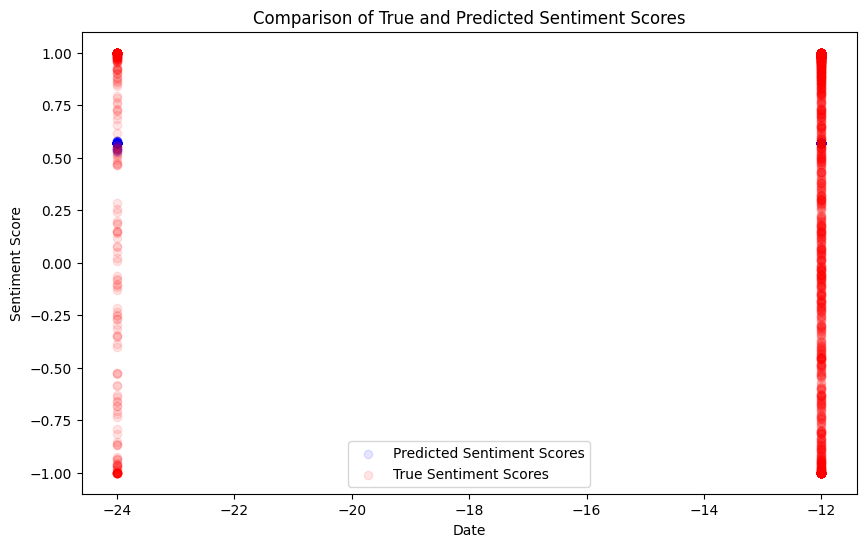

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(-test['review date(months ago)'], forecast, label='Predicted Sentiment Scores', c='b', alpha=0.1)
plt.scatter(-test['review date(months ago)'], test['Sentiment Score'], label='True Sentiment Scores', c ='r', alpha=0.1)
plt.title('Comparison of True and Predicted Sentiment Scores')
plt.xlabel('Date')
plt.ylabel('Sentiment Score')
plt.legend()
plt.show()

In [ ]:
print("Test Mean: ", np.mean(test['Sentiment Score']))
print("Predicted Mean: ", np.mean(forecast))
print("Test Median: ", np.median(test['Sentiment Score']))
print("Predicted Median: ", np.median(forecast))

Test Mean:  0.5215698
Predicted Mean:  0.5685292669405733
Test Median:  0.9856795
Predicted Median:  0.5686159297675519
